In [1]:
print("gello")

gello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# enlever les lignes vides
Liste_features_simple = ["Sex",
                         "Age"	, # poly lineariser sur 0 1
                         "Time H-ICU"	,
                         "TIME SYMPTOMES-ICU"	,
                         "Time  DG-ICU", 
                         "Hem_mal"	,# a transformer par dic
                         "Dis_status HEM" ,# a transformer par dic
                         "HSCT_BMT",#dicoto allo auto
                         "GvHD"	, # ?
                         "Sys_dis",
                         "Solid_tumor"	,
                         "Organ_transpl"	,
                         #"Organ_transpl_spec"	,# peut se faire
                         "Drug_induced"	, # enlever les " "
                         "Chemotherapy"	,# enlever les " "
                         "Ibr_Flu_Met"	,
                         "Immuno_drugs"	,
                         "Tar_ther"	,
                         "Immunotherapy"	,
                         "Carttcells"	,
                         "Steroids_YN",
                         "Prophylaxis_pneumocystis",
                         "Prophylaxis_antifungal",
                         "Prophylaxis_bacterial"	,
                         "Prophylaxis_viral",
                         "Vaccins#Flu",
                         "Vaccins#COVID",
                         "Vaccins#Other",
                         "SOFA_score", # lineariser
                         "Resp_rate", # faire un score catégoriser avec intubation/Sp02
                         "SpO2",
                         "Temp", #a linéariser
                         "Neutrophils", #a catégoriser + clean
                         "Leukocytes",

]


# Charger le fichier Excel
df = pd.read_excel('D:/EFRAIM3 JD VANCE.xlsx')
# statistiques
features_etiology =[
                    'Etiology_Bacterial infection_Definitive diagnosis',
                    'Etiology_Viral infection_Definitive diagnosis',
                    'Etiology_Invasive pulmonary aspergillosis_Definitive diagnosis',
                    'Etiology_Pneumocystis jirovecii infection_Definitive diagnosis',
                    'Etiology_Mucorales_Definitive diagnosis',
                    'Etiology_Other fungal (specify below)_Definitive diagnosis',
                    'Etiology_Other infection (specify below)_Definitive diagnosis',
                    'Etiology_Cardiogenic pulmonary oedema_Definitive diagnosis',
                    'Etiology_Drug related_Definitive diagnosis',
                    'Etiology_Disease-related infiltrates_Definitive diagnosis',
                    'Etiology_Transfusion-related acute lung injury_Definitive diagnosis',
                    'Etiology_Other causes (specify below)_Definitive diagnosis',
                    'Etiology_Undetermined cause_Definitive diagnosis'
                    ]

df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
df_col_utils = df[Liste_features_simple]
df_category = df[features_etiology]


In [31]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

sys.modules.pop('utils.visualisation', None)
sys.modules.pop('evaluation.evaluation', None)
sys.modules.pop('utils.data_aug', None)
sys.modules.pop('utils.models_and_metrics', None) 

<module 'utils.models_and_metrics' from 'c:\\Users\\Famiréa\\Desktop\\projects\\utils\\models_and_metrics.py'>

In [4]:

from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features
from utils.data_quality import nettoyer_nan_par_colonne
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","Resp_rate","Leukocytes"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features_simple
}

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)

✅ Nettoyage terminé. NaN restants : 0


In [25]:
# L = df_features_clean.columns
# print(L)
# print(df_features_clean.dtypes)

In [6]:
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
df_features_clean = nettoyer_lignes_vides(df_features_clean)

Nombre de lignes totalement vides : 2164
Nombre de lignes totalement vides : 0
Nombre de lignes totalement vides : 0


In [7]:
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'Other fungal' :["Other fungal (specify below)","Mucorales"] ,
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug related' : ['Drug related'],
                    'Other causes': ['Other causes (specify below)','Other infection (specify below)','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
print(df_cat_clean.columns)
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")

Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Pneumocystis jirovecii infection',
       'Mucorales', 'Other fungal (specify below)',
       'Other infection (specify below)', 'Cardiogenic pulmonary oedema',
       'Drug related', 'Disease-related infiltrates',
       'Transfusion-related acute lung injury',
       'Other causes (specify below)'],
      dtype='object')


In [8]:

sys.modules.pop('utils.algo_prediction', None)
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,entrainer_modele_multilabel,evaluer_modele_multilabel
print(len(df_features_clean), len(df_cat_clean))

# 2) Séparation X/y + split
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_fusion)  # ou fournir la liste

# 3) Normalisation (optionnel mais recommandé pour logreg/MLP)
X_train_sc, X_test_sc, scaler, cols_num = normaliser_features(X_train, X_test)

# 4) Entraîner (choisis "random_forest", "logreg_ovr" ou "mlp")
modele = entrainer_modele_multilabel(X_train_sc, y_train, type_modele="logreg_ovr")

# 5) Évaluer
_ = evaluer_modele_multilabel(modele, X_test_sc, y_test, seuil=0.4)


9415 7251


TypeError: entrainer_modele_multilabel() got an unexpected keyword argument 'type_modele'

In [10]:
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
from utils.models_and_metrics import compare_models_metric
from sklearn.linear_model import LogisticRegression

from utils.models_and_metrics import get_models,get_metric

for col in df_labels_fusion.columns:
    print("==== Traitement de la colonne :", col)
    models = get_models(y_train)
    # print(col, df_labels_fusion[col].sum())
    df_labels_1 = df_labels_fusion[col].to_frame()
    # 2) Séparation X/y + split
    X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_1)  # ou fournir la liste

    # 3) Normalisation (optionnel mais recommandé pour logreg/MLP)
    X_train_sc, X_test_sc, scaler, cols_num = normaliser_features(X_train, X_test)

    # 4) Entraîner (choisis "random_forest", "logreg_ovr" ou "mlp")
    # model, metrics = train_binary_classifier(X_train_sc, y_train, X_test_sc, y_test)
    # show_metrics_binary(metrics)

    model = LogisticRegression(class_weight="balanced", max_iter=10)
    #train_and_optimize_threshold_PR(model, X_train_sc, y_train, X_test_sc, y_test)
    # y_train = y_train.values.ravel()
    # y_test = y_test.values.ravel()

    # df_f1 = compare_models_metric(models,f1_score,
    # X_train_sc, y_train, X_test_sc, y_test
    # )



==== Traitement de la colonne : Bacterial infection

📊 Répartition des classes : pos=0.148, neg=0.852
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Traitement de la colonne : Viral infection

📊 Répartition des classes : pos=0.382, neg=0.618
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

==== Traitement de la colonne : Invasive pulmonary aspergillosis

📊 Répartition des classes : pos=0.253, neg=0.747
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

==== Traitement de la colonne : Other fungal

📊 Répartition des classes : pos=0.045, neg=0.955
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Traitement de la colonne : Pneumocystis jirovecii infection

📊 Répartition des classes : pos=0.047, neg=0.953
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Traitement de la colonne : C


📊 Répartition des classes : pos=0.297, neg=0.703
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

dict_keys(['No Augmentation', 'RandomOverSampler', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'RandomUnderSampler', 'SMOTEENN', 'SMOTETomek'])
dict_keys(['accuracy', 'precision', 'recall', 'f1', 'f_beta', 'roc_auc', 'pr_auc', 'logloss', 'brier', 'at_least_one_correct', 'negative_predictive_value', 'reject_n_lowest_correct'])
Utilisation du seuil = 0.5
🎯 F1-score : 0.4249
🔎 Accuracy : 0.7202


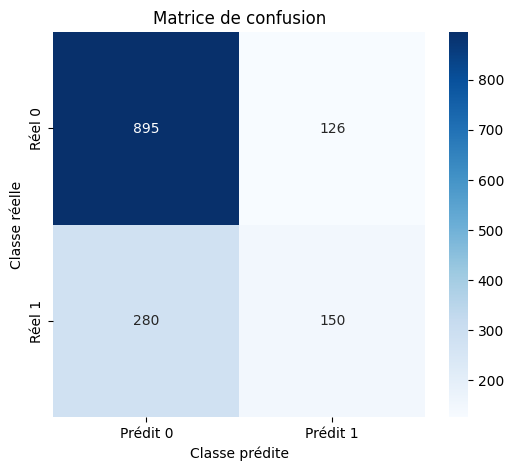

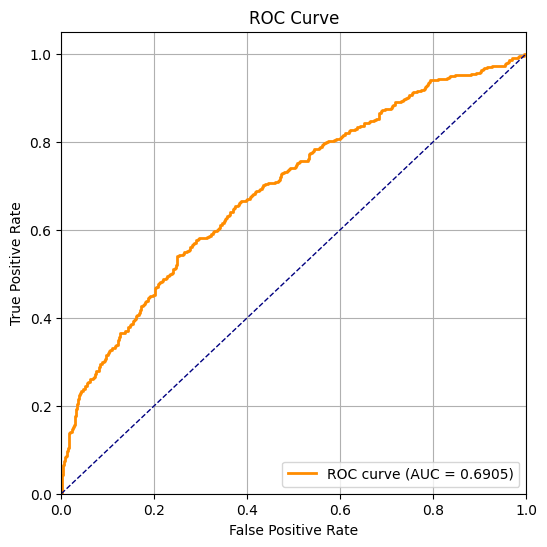

ROC AUC = 0.6905


0.690465344053937

In [32]:
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve


X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_1)  

models = get_models(y_train)
augmentations = get_augmentation_methods(random_state=0)
print(augmentations.keys())


pipe_train = Pipeline([
    ("scaler", AutoStandardScaler()),
    ("augmentation", augmentations['SMOTE']),
    ("model",models['XGBoost'] )
])
pipe_train.set_params(model__eval_metric=f1_metric_xgb)


pipe_train.fit(X_train, y_train)

metrics = get_metric()
print(metrics.keys())
metric_fn=metrics['roc_auc']["metric_fn"]
needs_proba=metrics['roc_auc']["needs_proba"]


pipe_test = Pipeline([
    ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
    ("model", pipe_train.named_steps["model"])     # modèle déjà fit
])
if needs_proba:
    y_pred = pipe_test.predict_proba(X_test)[:, 1]
else:
    y_pred = pipe_test.predict(X_test)
    
score = metric_fn(y_test, y_pred)
show_metrics_binary(y_test, y_pred)
show_roc_curve(y_test, y_pred)

In [37]:
sys.modules.pop('utils.feature_importance', None)
from utils.feature_importance import shap_top10_per_estimator,plot_top10_features_per_estimator
plot_top10_features_per_estimator(modele,feature_names=X_train.columns,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/importance')
shap_top10_per_estimator(model= modele,X = X_test_sc,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/shap')


===== SHAP pour estimateur (classe Bacterial infection) =====

===== SHAP pour estimateur (classe Viral infection) =====

===== SHAP pour estimateur (classe Invasive pulmonary aspergillosis) =====

===== SHAP pour estimateur (classe Other fungal) =====

===== SHAP pour estimateur (classe Pneumocystis jirovecii infection) =====

===== SHAP pour estimateur (classe Cardiogenic pulmonary oedema) =====

===== SHAP pour estimateur (classe Disease-related infiltrates) =====

===== SHAP pour estimateur (classe Drug related) =====

===== SHAP pour estimateur (classe Other causes) =====


In [50]:
from utils.algo_prediction import metrics_of_predictions
df_suspected_fusion = fusionner_labels(df_suspected, mapping_etiology, mode="max")
index_y_true = df_labels_fusion.index
index_suspected = df_suspected_fusion.index
intersection = index_y_true.intersection(index_suspected)
print(df_labels_fusion.loc[intersection].shape,df_suspected_fusion.loc[intersection].shape)
metrics_of_predictions(df_labels_fusion.loc[intersection],df_suspected_fusion.loc[intersection])

(7240, 7) (7240, 7)
=== Rapport par étiquette ===
              precision    recall  f1-score   support

           0       0.49      0.93      0.64      2767
           1       0.53      0.94      0.68      1835
           2       0.38      0.79      0.51       624
           3       0.26      0.86      0.40       333
           4       0.59      0.90      0.71       840
           5       0.63      0.95      0.76       774
           6       0.76      0.92      0.83      2345

   micro avg       0.54      0.92      0.68      9518
   macro avg       0.52      0.90      0.65      9518
weighted avg       0.57      0.92      0.69      9518
 samples avg       0.62      0.82      0.67      9518

Métrique partial match score 
0.8451657458563536
Score 'au moins 4 labels négatifs bien rejetés' = 0.92
=== Métriques globales ===
hamming_loss: 0.1628
f1_micro: 0.6791
f1_macro: 0.6480
jaccard_micro: 0.5141
jaccard_macro: 0.4936


{'hamming_loss': 0.16282557221783742,
 'f1_micro': 0.6790603609209708,
 'f1_macro': 0.6480040154876673,
 'jaccard_micro': 0.514073725120716,
 'jaccard_macro': 0.49360366950674867}

In [ ]:
Implémenter from sklearn.model_selection import StratifiedKFold
